### История моих страданий

Ниже дневник экспериментов. Начал я с того, что воспроизвел бэйзлайн. Следующие несколько экспериментов я придумывал новые фичи и пытался улучшить этот бэйзлайн. На 200 итарациях, чтобы можно было быстро итерировать эксперименты. Из хороших фичей нашлась категориальная фича "любимая категория". Остальное влияло на уровне шума.

После этого я понял, что 200 итераций - слишком мало, чтобы не самые важные фичи могли проявиться. Сделал подбор параметоров и все дальнейшие эксперименты идут до переобучения и занимают примерно по 1000 итераций. После этого ряд экспериментов был повторен и заметно, что многие новые фичи давали небольшой прирост.

Дальше я почти случайно получил свой лучший скор. Когда я посмотрел, за какой период у нас есть данные - я это смотрел просто по дате первого события. не глянув на разбивку. А первое событие было в 2011. Раз у нас много данных, я начал увеличивать период обучения. И скор, внезапно, сильно вырос. Почему так - не знаю. Больше похоже на то, что модель случайно что-то поймала. Адекватные данные у нас есть только с марта. Поэтому увеличение горизонта с 3 до 4 месяцев могло на что-то повлиять для теста, так как мы добавляем лишный месяц тесту учиться. Хотя уже это сомнительно, т.к. у трейна такой возможности нет. А вот добавление месяцев сверху - это добавление каких-то единичных наблюдений. Которые странным образом улучшили скор на тесте, но снили скор на вале. Итого лучший скор на 12 месяцах.

Затем я уменьшил окно до 6 и продолжил геренацию фичей. Так как самой удачной фичей була топ-категория, попробовал расширить до 3х. Но просто добавление 3х топ столбцов привело к ухудшению. Вместо этого сделал SVD по категориям и там взять три. Это показало себя чуть лучше, чем просто топ1.

Как итог скор на тесте оказался на уровне "12-месячного" (exp 10), но если тот больше похож на удачу, итоговой модели я больше доверяю. Я попробовал в итоговой модели снова провернуть трюк с увеличением окна, но на этот раз скор упал. Видимо, удалось поймать нормальными признаками то, что там ловилось удачей.

In [ ]:
# Дневник экспериментов:
# Точка отсчета (Baseline 1): 0.81725 (Public LB) / 0.7587 (Local OOT Eval)
# Эксперимент 1 (Добавление действия view): +0.00005 (нет значимого эффекта, откат)
# Эксперимент 2 (Фичи за 14 дней): +0.00003 (нет значимого эффекта, откат).
# Эксперимент 3 (Конверсии: click->cart->order): bestTest = 0.75895, base1+0.00021.
# Эксперимент 4 (Расширенные конверсии и средний чек): -0.00001 (откат).
# Эксперимент 5 (Разнообразие товаров и категорий): -0.00004 (откат)
# Эксперимент 6 (Любимые категории заказа и клика): bestTest = 0.75929, exp3+0.00034 (Local) -> 0.81814 (Public)
# -------------
# ====================================================================
# Новый бейзлайн (После тюнинга CatBoost)
# * Local AUC: 0.76012 | Public AUC: 0.81845
# * Изменения: Подобрали гиперпараметры (Depth=7, LR=0.0375, L2), увеличили лимит итераций до 1500 (сходится примерно на 1000-й).
# Эксперимент 8 - повторяем эксперимент 2. bestTest = 0.76019
# Эксперимент 9 - увеличиваем окно до 8 месяцев. bestTest = 0.76044 -> 0.82112 (Public)
# Эксперимент 10 - увеличиваем окно до 12 месяцев. bestTest = 0.76028 -> 0.82173 (Public)
# Эксперимент 11 - добавляем средний чек. bestTest = 0.76042 -> 0.82125 (Public)
# Эксперимент 12 - уменьшаем окно до 6, чтобы рандомно не подстраиваться под паблик тест. bestTest = 0.76048 -> 0.82092 (Public)
# Эксперимент 13 - тренд кликов. bestTest = 0.76041 -> 0.82145 (Public)
# Эксперимент 14 - Замена Топ-1 категории на Топ-3. bestTest = 0.76004 (Откат)
# Эксперимент 15 - SVD категорий. bestTest = 0.76050 -> 0.82169 (Public)
# Эксперимент 16 - Снова год для финального сабмита bestTest = 0.76060 -> 0.82158 (Public)

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import catboost
import os
from datetime import date, timedelta
from sklearn.decomposition import TruncatedSVD

# Константы путей
DATA_PATH = '/kaggle/input/competitions/predict-user-fresh-order'

# Временные окна (из бейзлайна)
TEST_START_DATE = date(2024, 8, 1)

VAL_START_DATE = date(2024, 7, 1)
VAL_END_DATE = date(2024, 7, 31)
TRAIN_END_DATE = date(2024, 6, 30)

LOOKBACK_DAYS = 30 * 12

In [23]:
# Используем lazy execution для экономии памяти, пока не потребуется collect()
actions_lazy = pl.scan_parquet(os.path.join(DATA_PATH, 'actions_history/*.parquet'))
search_lazy = pl.scan_parquet(os.path.join(DATA_PATH, 'search_history/*.parquet'))
products = pl.read_csv(os.path.join(DATA_PATH, 'product_information.csv'))
test_users = pl.read_csv(os.path.join(DATA_PATH, 'test_users.csv'))

In [ ]:
def get_target(actions_lazy, start_date, end_date):
    """Собирает таргет (наличие покупки) в заданном окне."""
    return (
        actions_lazy
        .filter(pl.col('timestamp').dt.date() >= start_date)
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .select('user_id', (pl.col('action_type_id') == 3).alias('has_order'))
        .group_by('user_id')
        .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
    ).collect()

def get_base_features(actions_lazy, search_lazy, products, end_date, target_start_date):
    """Генерирует базовые признаки за LOOKBACK_DAYS до end_date."""
    start_date = end_date - timedelta(days=LOOKBACK_DAYS)

    # 1. Фичи по действиям
    actions_id_to_suf = {1: "click", 2: "favorite", 3: "order", 5: "to_cart"}
    dfs = []

    for id_, suf in actions_id_to_suf.items():
        aggs = (
            actions_lazy
            .filter(pl.col('timestamp').dt.date() <= end_date)
            .filter(pl.col('timestamp').dt.date() >= start_date)
            .filter(pl.col('action_type_id') == id_)
            .join(products.lazy().select('product_id', 'discount_price'), on='product_id')
            .group_by('user_id')
            .agg(
                pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
                pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
                pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
                pl.max('timestamp').alias(f'last_{suf}_time'),
                pl.min('timestamp').alias(f'first_{suf}_time'),
            )
            .with_columns([
                (pl.lit(target_start_date) - pl.col(f'last_{suf}_time')).dt.total_days().cast(pl.Int32).alias(f'days_since_last_{suf}'),
                (pl.lit(target_start_date) - pl.col(f'first_{suf}_time')).dt.total_days().cast(pl.Int32).alias(f'days_since_first_{suf}'),
            ])
            .select('user_id', f'num_products_{suf}', f'sum_discount_price_{suf}', f'max_discount_price_{suf}', f'days_since_last_{suf}', f'days_since_first_{suf}')
        )
        dfs.append(aggs.collect())

    # 2. Фичи по поиску
    search_aggs = (
        search_lazy
        .filter(pl.col('action_type_id') == 4)
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
        .group_by('user_id')
        .agg(
            pl.count('search_query').cast(pl.Int32).alias('num_search'),
            pl.max('timestamp').alias('last_search_time'),
            pl.min('timestamp').alias('first_search_time'),
        )
        .with_columns([
            (pl.lit(target_start_date) - pl.col('last_search_time')).dt.total_days().cast(pl.Int32).alias('days_since_last_search'),
            (pl.lit(target_start_date) - pl.col('first_search_time')).dt.total_days().cast(pl.Int32).alias('days_since_first_search'),
        ])
        .select('user_id', 'num_search', 'days_since_last_search', 'days_since_first_search')
    )
    dfs.append(search_aggs.collect())

    # 3. Сборка
    res_df = dfs[0]
    for df in dfs[1:]:
        res_df = res_df.join(df, on='user_id', how='full', coalesce=True)

    return res_df

def get_recent_features(actions_lazy, end_date, window_days=14):
    """Считает количество действий юзера за последние window_days дней."""
    start_date = end_date - timedelta(days=window_days)

    # 1. Фильтруем и агрегируем (пока в ленивом режиме)
    recent_lazy = (
        actions_lazy
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
        .group_by(['user_id', 'action_type_id'])
        .agg(pl.len().cast(pl.Int32).alias('cnt'))
    )

    # 2. Вызываем collect() перед pivot, так как pivot меняет схему
    recent_features = (
        recent_lazy.collect()
        .pivot(index="user_id", on="action_type_id", values="cnt")
        .fill_null(0)
    )

    # Словарь для переименования
    rename_dict = {
        "1": f"click_last_{window_days}d",
        "2": f"favorite_last_{window_days}d",
        "3": f"order_last_{window_days}d",
        "5": f"to_cart_last_{window_days}d",
    }

    rename_mapping = {col: rename_dict[col] for col in recent_features.columns if col in rename_dict}
    return recent_features.rename(rename_mapping)

def get_diversity_features(actions_lazy, products, end_date):
    """Считает количество уникальных товаров и категорий в заказах юзера."""
    start_date = end_date - timedelta(days=LOOKBACK_DAYS)

    diversity_features = (
        actions_lazy
        # Берем только заказы (action_type_id == 3)
        .filter(pl.col('action_type_id') == 3)
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
        # Джойним справочник товаров, чтобы достать category_id
        .join(products.lazy().select('product_id', 'category_id'), on='product_id')
        .group_by('user_id')
        .agg(
            pl.n_unique('product_id').cast(pl.Int32).alias('unique_products_ordered'),
            pl.n_unique('category_id').cast(pl.Int32).alias('unique_categories_ordered')
        )
    )

    return diversity_features.collect()

def add_conversion_features(df_pl):
    return df_pl.with_columns([
        # --- Старые конверсии ---
        pl.when(pl.col('num_products_click') > 0)
          .then(pl.col('num_products_to_cart') / pl.col('num_products_click'))
          .otherwise(0.0).alias('conv_click_to_cart'),

        pl.when(pl.col('num_products_to_cart') > 0)
          .then(pl.col('num_products_order') / pl.col('num_products_to_cart'))
          .otherwise(0.0).alias('conv_cart_to_order'),

        # --- НОВЫЕ: Средние чеки и цены ---
        pl.when(pl.col('num_products_order') > 0)
          .then(pl.col('sum_discount_price_order') / pl.col('num_products_order'))
          .otherwise(0.0).alias('avg_price_order'),

        pl.when(pl.col('num_products_click') > 0)
          .then(pl.col('sum_discount_price_click') / pl.col('num_products_click'))
          .otherwise(0.0).alias('avg_price_click')
    ])

def get_favorite_categories(actions_lazy, products, end_date):
    """Возвращаем старую, надежную функцию для Топ-1 категории."""
    start_date = end_date - timedelta(days=LOOKBACK_DAYS)

    actions_with_cat = (
        actions_lazy
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
        .filter(pl.col('action_type_id').is_in([1, 3]))
        .join(products.lazy().select('product_id', 'category_id'), on='product_id')
    )

    top_order_cat = (
        actions_with_cat.filter(pl.col('action_type_id') == 3)
        .group_by(['user_id', 'category_id']).agg(pl.len().alias('cnt'))
        .sort('cnt', descending=True)
        .unique(subset=['user_id'], keep='first')
        .select('user_id', pl.col('category_id').alias('top_category_order'))
    )

    top_click_cat = (
        actions_with_cat.filter(pl.col('action_type_id') == 1)
        .group_by(['user_id', 'category_id']).agg(pl.len().alias('cnt'))
        .sort('cnt', descending=True)
        .unique(subset=['user_id'], keep='first')
        .select('user_id', pl.col('category_id').alias('top_category_click'))
    )

    return top_order_cat.join(top_click_cat, on='user_id', how='full', coalesce=True).collect()

def get_category_svd_features(actions_lazy, products, end_date, n_components=5):
    """Строит SVD-векторы ('мета-категории') на основе покупок пользователя."""
    start_date = end_date - timedelta(days=LOOKBACK_DAYS)

    # Считаем количество покупок каждой категории
    user_cat_matrix = (
        actions_lazy
        .filter(pl.col('action_type_id') == 3)
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
        .join(products.lazy().select('product_id', 'category_id'), on='product_id')
        .group_by(['user_id', 'category_id'])
        .agg(pl.len().alias('order_count'))
        .collect()
    ).to_pandas()

    # Берем топ-100 категорий, чтобы отсеять мусор и ускорить SVD
    top_cats = user_cat_matrix['category_id'].value_counts().nlargest(100).index
    df_filtered = user_cat_matrix[user_cat_matrix['category_id'].isin(top_cats)]

    # Строим user-item матрицу
    pivot_df = df_filtered.pivot(index='user_id', columns='category_id', values='order_count').fillna(0)

    # Сжимаем 100 категорий в 5 скрытых факторов (кластеров)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    svd_features = svd.fit_transform(pivot_df)

    # Собираем результат обратно в Polars
    res_df = pl.DataFrame(svd_features, schema=[f"cat_svd_{i}" for i in range(n_components)])
    res_df = res_df.with_columns(pl.Series("user_id", pivot_df.index))

    return res_df

def get_trend_features(actions_lazy, end_date):
    """Считает долю покупок и кликов в последний месяц относительно всей истории."""
    month_ago = end_date - timedelta(days=30)
    start_date = end_date - timedelta(days=LOOKBACK_DAYS)

    base_lazy = (
        actions_lazy
        .filter(pl.col('action_type_id').is_in([1, 3]))
        .filter(pl.col('timestamp').dt.date() <= end_date)
        .filter(pl.col('timestamp').dt.date() >= start_date)
    )

    trends = (
        base_lazy
        .group_by('user_id')
        .agg([
            pl.col('action_type_id').filter(pl.col('action_type_id') == 3).len().alias('total_orders'),
            pl.col('action_type_id').filter(
                (pl.col('action_type_id') == 3) & (pl.col('timestamp').dt.date() > month_ago)
            ).len().alias('recent_orders'),

            pl.col('action_type_id').filter(pl.col('action_type_id') == 1).len().alias('total_clicks'),
            pl.col('action_type_id').filter(
                (pl.col('action_type_id') == 1) & (pl.col('timestamp').dt.date() > month_ago)
            ).len().alias('recent_clicks')
        ])
        .with_columns([
            (pl.col('recent_orders') / pl.col('total_orders').replace(0, 1)).alias('order_trend'),
            (pl.col('recent_clicks') / pl.col('total_clicks').replace(0, 1)).alias('click_trend')
        ])
        .select(['user_id', 'order_trend', 'click_trend'])
    )

    return trends.collect()

In [ ]:
# ==========================================
# СБОРКА TRAIN
# ==========================================
print("Собираем Train...")
train_target = get_target(actions_lazy, VAL_START_DATE, VAL_END_DATE)
train_features = get_base_features(actions_lazy, search_lazy, products, TRAIN_END_DATE, VAL_START_DATE)
train_fav_cats = get_favorite_categories(actions_lazy, products, TRAIN_END_DATE) # Вернули старую
train_recent = get_recent_features(actions_lazy, TRAIN_END_DATE, window_days=14)
train_trend = get_trend_features(actions_lazy, TRAIN_END_DATE)
train_svd = get_category_svd_features(actions_lazy, products, TRAIN_END_DATE, n_components=5) # НОВОЕ

df_train_pl = (
    train_target
    .join(train_features, on='user_id', how='left')
    .join(train_fav_cats, on='user_id', how='left')
    .join(train_recent, on='user_id', how='left')
    .join(train_trend, on='user_id', how='left')
    .join(train_svd, on='user_id', how='left') # НОВОЕ
    .fill_null(0)
)

df_train_pl = add_conversion_features(df_train_pl)

cat_cols = ['top_category_order', 'top_category_click'] # Вернули старые кат. фичи
df_train_pl = df_train_pl.with_columns([
    pl.col(c).fill_null(-1).cast(pl.Int32) for c in cat_cols
])

df_train = df_train_pl.to_pandas()

# ==========================================
# СБОРКА TEST
# ==========================================
print("Собираем Test...")
test_features = get_base_features(actions_lazy, search_lazy, products, VAL_END_DATE, TEST_START_DATE)
test_fav_cats = get_favorite_categories(actions_lazy, products, VAL_END_DATE)
test_recent = get_recent_features(actions_lazy, VAL_END_DATE, window_days=14)
test_trend = get_trend_features(actions_lazy, VAL_END_DATE)
test_svd = get_category_svd_features(actions_lazy, products, VAL_END_DATE, n_components=5) # НОВОЕ

df_test_pl = (
    test_users
    .join(test_features, on='user_id', how='left')
    .join(test_fav_cats, on='user_id', how='left')
    .join(test_recent, on='user_id', how='left')
    .join(test_trend, on='user_id', how='left')
    .join(test_svd, on='user_id', how='left') # НОВОЕ
    .fill_null(0)
)

df_test_pl = add_conversion_features(df_test_pl)

df_test_pl = df_test_pl.with_columns([
    pl.col(c).fill_null(-1).cast(pl.Int32) for c in cat_cols
])

df_test = df_test_pl.to_pandas()

print("Сборка завершена!")

Собираем Train...
Собираем Test...
Сборка завершена!


In [ ]:
# Фичи для обучения
cols = [c for c in df_train.columns if c not in ['user_id', 'target']]
cat_features = ['top_category_order', 'top_category_click']

# Сплит
mask = df_train.user_id % 10 <= 6
train_pool = catboost.Pool(
    df_train.loc[mask, cols],
    label=df_train.loc[mask].target,
    cat_features=cat_features # Передаем в пул
)
eval_pool = catboost.Pool(
    df_train.loc[~mask, cols],
    label=df_train.loc[~mask].target,
    cat_features=cat_features # Передаем в пул
)

params = {
    'iterations': 1500,
    'learning_rate': 0.0375,
    'depth': 7,
    'score_function': 'L2',
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'task_type': 'CPU',
    'random_seed': 42,
    'early_stopping_rounds': 50
}

model = catboost.CatBoost(params)
model.fit(
    train_pool,
    eval_set=eval_pool,
    use_best_model=True,
    verbose=50,
    early_stopping_rounds=50,
)

model.save_model("baseline1.bin")

# Feature Importance
fi = model.get_feature_importance(eval_pool, prettified=True)
display(fi.head(10))

0:	test: 0.7468722	best: 0.7468722 (0)	total: 974ms	remaining: 24m 19s
50:	test: 0.7557650	best: 0.7557650 (50)	total: 45.3s	remaining: 21m 25s
100:	test: 0.7574368	best: 0.7574377 (99)	total: 1m 29s	remaining: 20m 38s
150:	test: 0.7582331	best: 0.7582530 (148)	total: 2m 16s	remaining: 20m 18s
200:	test: 0.7588092	best: 0.7588092 (200)	total: 3m	remaining: 19m 28s
250:	test: 0.7590244	best: 0.7590267 (249)	total: 3m 51s	remaining: 19m 11s
300:	test: 0.7593144	best: 0.7593144 (300)	total: 4m 36s	remaining: 18m 23s
350:	test: 0.7595909	best: 0.7595909 (350)	total: 5m 21s	remaining: 17m 32s
400:	test: 0.7597065	best: 0.7597262 (396)	total: 6m 5s	remaining: 16m 42s
450:	test: 0.7598134	best: 0.7598134 (450)	total: 6m 49s	remaining: 15m 53s
500:	test: 0.7599282	best: 0.7599359 (495)	total: 7m 47s	remaining: 15m 31s
550:	test: 0.7599860	best: 0.7599981 (533)	total: 8m 33s	remaining: 14m 44s
600:	test: 0.7600565	best: 0.7600671 (583)	total: 9m 17s	remaining: 13m 54s
650:	test: 0.7601450	best:

,Feature Id,Importances
0,cat_svd_0,12.986658
1,days_since_first_order,6.910272
2,sum_discount_price_to_cart,6.385876
3,order_trend,5.958748
4,sum_discount_price_order,5.850519
5,num_search,5.790506
6,conv_click_to_cart,5.411293
7,days_since_last_order,5.187676
8,days_since_last_to_cart,3.711528
9,num_products_click,3.147683


In [27]:
df_test['predict'] = model.predict(df_test[cols], prediction_type="Probability")[:, 1]
submission = df_test[['user_id', 'predict']]
submission.to_csv('baseline1_submission.csv', index=False)
print("Сабмит сохранен!")

Сабмит сохранен!


Анализ значимости признаков

--- CatBoost Built-in Feature Importance ---


,Feature Id,Importances
0,cat_svd_0,12.986658
1,days_since_first_order,6.910272
2,sum_discount_price_to_cart,6.385876
3,order_trend,5.958748
4,sum_discount_price_order,5.850519
5,num_search,5.790506
6,conv_click_to_cart,5.411293
7,days_since_last_order,5.187676
8,days_since_last_to_cart,3.711528
9,num_products_click,3.147683



--- SHAP Summary Plot ---


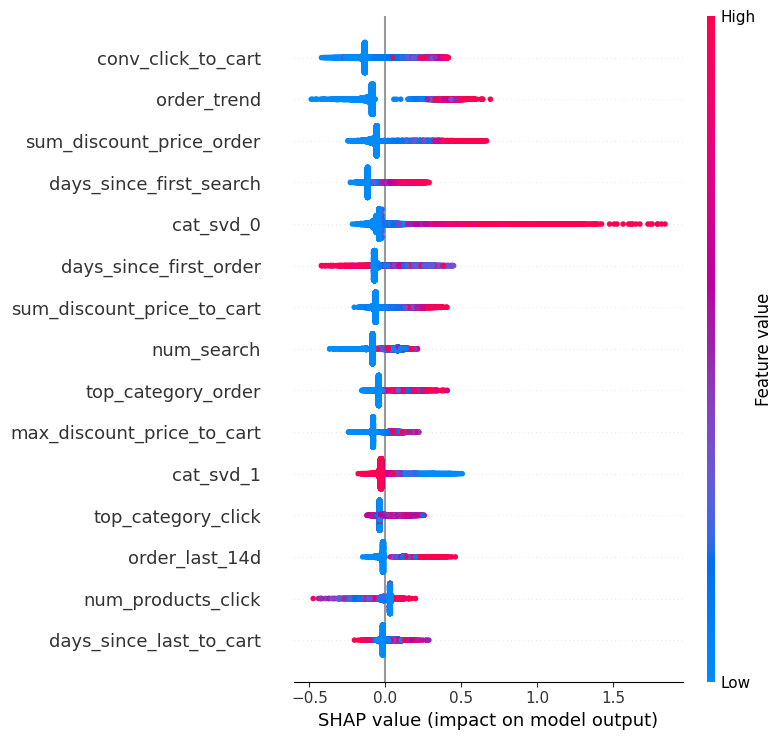

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Feature Importance от самого CatBoost
print("--- CatBoost Built-in Feature Importance ---")
fi = model.get_feature_importance(eval_pool, prettified=True)
display(fi.head(20))

print("\n--- SHAP Summary Plot ---")
# SHAP считается долго на всем датасете, поэтому возьмем случайную подвыборку из валидации
X_eval = df_train.loc[~mask, cols]
X_eval_sample = X_eval.sample(n=10000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_eval_sample)

shap.summary_plot(shap_values, X_eval_sample, max_display=15)

Код для подбора параметров. Вывод ячеек не сохранился. Но, в целом, функция на результат не влияла. Деревья с маленькой глубиной не успевали за 1500 итераций сойтись к хорошему результату. Деревья с глубиной 7 приходили к переобучению примерно за 1000 итераций (10-15 минут). Размер шага заметно влиял на результат. 

In [ ]:
# import optuna
# import catboost
# import pandas as pd

# n_trials=10


# def objective(trial):
#     # 1. Сначала Optuna должна сгенерировать параметры
#     params = {
#         'iterations': 1500,
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'depth': trial.suggest_int('depth', 2, 7),
#         'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),
#         'eval_metric': 'AUC',
#         'loss_function': 'Logloss',
#         'task_type': 'CPU',
#         'random_seed': 42,
#         'early_stopping_rounds': 50
#     }

#     # 2. Теперь мы можем их напечатать
#     print(f"\n[{trial.number + 1}/{n_trials} Начинаем Trial. Параметры: LR={params['learning_rate']:.4f}, Depth={params['depth']}, Score={params['score_function']}")

#     cb_model = catboost.CatBoostClassifier(**params)
#     cb_model.fit(
#         train_pool,
#         eval_set=eval_pool,
#         verbose=400, # Поставил 400, чтобы не слишком спамило, но показывало прогресс
#         use_best_model=True
#     )

#     best_auc = cb_model.get_best_score()['validation']['AUC']
#     print(f"[*] Trial {trial.number + 1} завершен. AUC: {best_auc}\n")
#     return best_auc

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=n_trials)

# # 3. Анализ результатов!
# print("\n--- История всех запусков ---")
# history_df = study.trials_dataframe()

# # Оставляем только нужные колонки для анализа и сортируем по метрике
# res_cols = ['value', 'params_depth', 'params_learning_rate', 'params_score_function', 'state']
# history_df = history_df[res_cols].sort_values('value', ascending=False)

# display(history_df)
# history_df.to_csv('optuna_history.csv', index=False)
# print("Полная история сохранена в optuna_history.csv")

Тут я посмотрел на данные и узнал, что несмотря на то, что "данные с 2011 года" ,по факту они с марта 2024г.

In [ ]:
import polars as pl

def check_monthly_data(actions_lazy):
    print("--- Распределение действий по месяцам ---")
    monthly_stats = (
        actions_lazy
        .with_columns([
            pl.col('timestamp').dt.year().alias('year'),
            pl.col('timestamp').dt.month().alias('month')
        ])
        .group_by(['year', 'month'])
        .agg(pl.len().alias('actions_count'))
        .sort(['year', 'month'])
    ).collect()

    pl.Config.set_tbl_rows(24)
    print(monthly_stats)

check_monthly_data(actions_lazy)

--- Распределение действий по месяцам ---
shape: (13, 3)
┌──────┬───────┬───────────────┐
│ year ┆ month ┆ actions_count │
│ ---  ┆ ---   ┆ ---           │
│ i32  ┆ i8    ┆ u32           │
╞══════╪═══════╪═══════════════╡
│ 2011 ┆ 5     ┆ 1             │
│ 2019 ┆ 1     ┆ 1             │
│ 2022 ┆ 2     ┆ 1             │
│ 2023 ┆ 10    ┆ 3             │
│ 2023 ┆ 11    ┆ 6             │
│ 2023 ┆ 12    ┆ 6             │
│ 2024 ┆ 1     ┆ 1             │
│ 2024 ┆ 2     ┆ 68991         │
│ 2024 ┆ 3     ┆ 37550650      │
│ 2024 ┆ 4     ┆ 33272268      │
│ 2024 ┆ 5     ┆ 35100061      │
│ 2024 ┆ 6     ┆ 37336579      │
│ 2024 ┆ 7     ┆ 38672976      │
└──────┴───────┴───────────────┘
